# Matplotlib gallery: sizes, colors, styles, and image output.

This notebook shows a variety of matplotlib plot types and how figure size, DPI, colormaps, line styles, markers, transparency, and themes affect the final image.

In [70]:
%matplotlib inline
import matplotlib.pyplot as plt
print("Interactive backend (notebook) enabled.")

Interactive backend (notebook) enabled.


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Reproducibility
np.random.seed(42)

# Sample data
x = np.linspace(0, 10, 400)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.exp(-x / 8)

scatter_x = np.random.randn(300)
scatter_y = 0.5 * scatter_x + np.random.randn(300) * 0.8
sizes = np.random.uniform(20, 300, size=300)
colors = np.random.uniform(0, 1, size=300)

categories = ['A', 'B', 'C', 'D', 'E']
values = [5, 8, 3, 7, 6]

image_data = np.outer(np.sin(np.linspace(0, 3*np.pi, 200)), np.cos(np.linspace(0, 3*np.pi, 300)))

print('Imports and sample data ready.')

Imports and sample data ready.


## 1) Same data, different figure sizes

Figure size changes the dimensions of the rendered image. Larger figures give more room for labels, legends, and data.

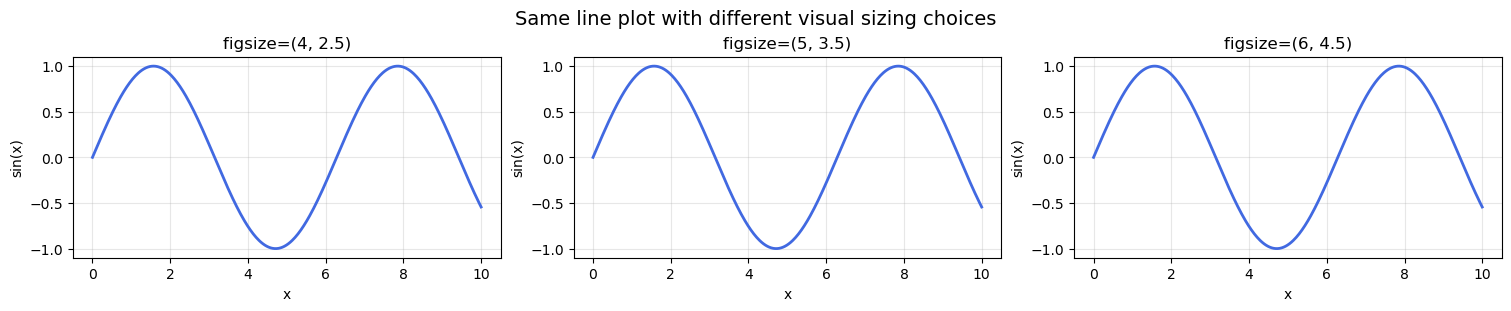

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)
fig.suptitle('Same line plot with different visual sizing choices', fontsize=14)

size_settings = [(4, 2.5), (5, 3.5), (6, 4.5)]
for ax, sz in zip(axes, size_settings):
    ax.plot(x, y1, color='royalblue', linewidth=2)
    ax.set_title(f'figsize={sz}')
    ax.set_xlabel('x')
    ax.set_ylabel('sin(x)')
    ax.grid(alpha=0.3)

plt.show()

## 2) Line styles, widths, markers, and colors

This compares several visual encodings for line charts.

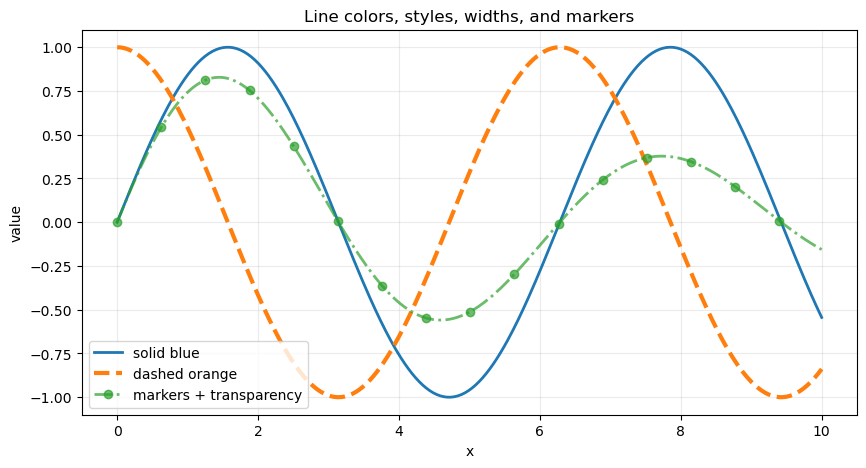

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y1, label='solid blue', color='tab:blue', linewidth=2)
ax.plot(x, y2, label='dashed orange', color='tab:orange', linestyle='--', linewidth=3)
ax.plot(x, y3, label='markers + transparency', color='tab:green', linestyle='-.', linewidth=2,
        marker='o', markevery=25, alpha=0.7)
ax.set_title('Line colors, styles, widths, and markers')
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

## 3) Scatter plot with varying marker size and color

This is useful for showing extra dimensions of information.

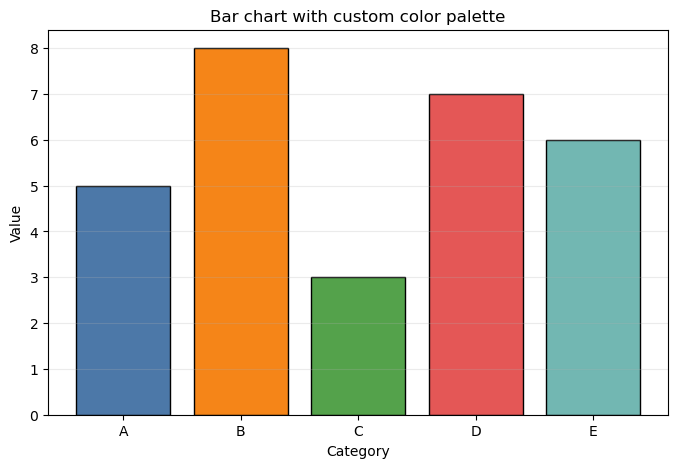

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']
ax.bar(categories, values, color=bar_colors, edgecolor='black', linewidth=1.0)
ax.set_title('Bar chart with custom color palette')
ax.set_xlabel('Category')
ax.set_ylabel('Value')
ax.grid(axis='y', alpha=0.25)
plt.show()

## 4) Bar chart with custom colors

Bar charts are a good place to compare categorical color choices.

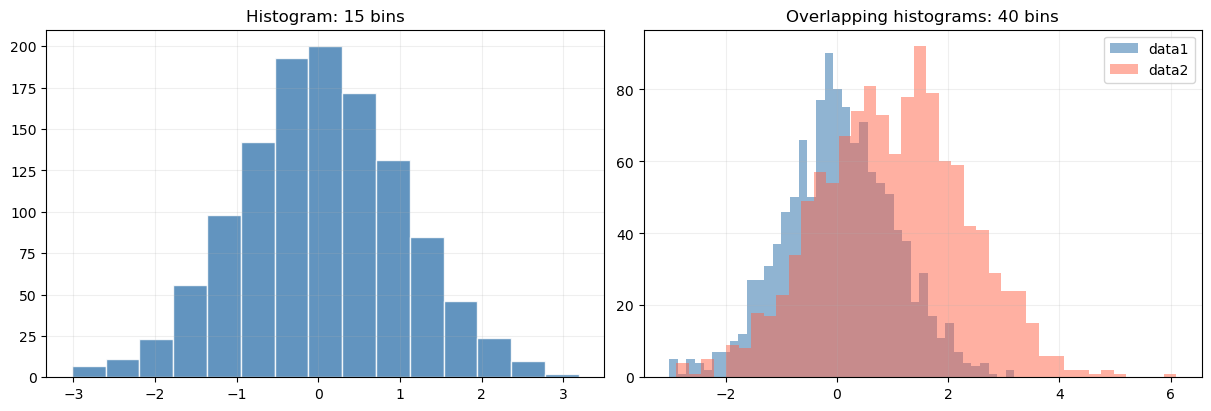

In [75]:
data1 = np.random.normal(loc=0, scale=1.0, size=1200)
data2 = np.random.normal(loc=1.0, scale=1.3, size=1200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(data1, bins=15, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Histogram: 15 bins')
axes[0].grid(alpha=0.2)

axes[1].hist(data1, bins=40, color='steelblue', alpha=0.6, label='data1')
axes[1].hist(data2, bins=40, color='tomato', alpha=0.5, label='data2')
axes[1].set_title('Overlapping histograms: 40 bins')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.show()

## 5) Histograms with transparency and different bin counts

Bins and alpha strongly affect how distributions look.

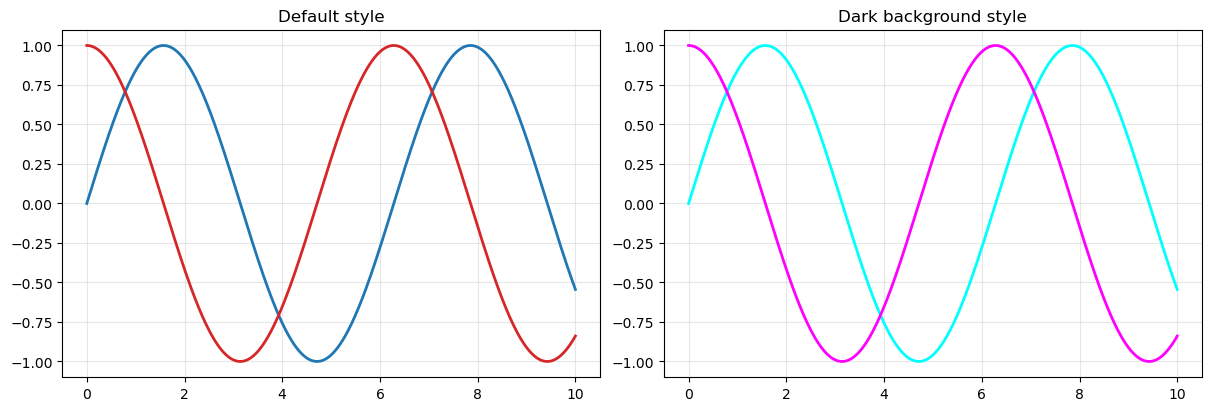

In [76]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(x, y1, color='tab:blue', linewidth=2)
axes[0].plot(x, y2, color='tab:red', linewidth=2)
axes[0].set_title('Default style')
axes[0].grid(alpha=0.3)

plt.style.use('dark_background')
axes[1].plot(x, y1, color='cyan', linewidth=2)
axes[1].plot(x, y2, color='magenta', linewidth=2)
axes[1].set_title('Dark background style')
axes[1].grid(alpha=0.3)

plt.show()
plt.style.use('default')  # reset for later cells

## 6) Subplots and themes

A dark background can make colors and lines appear very different.

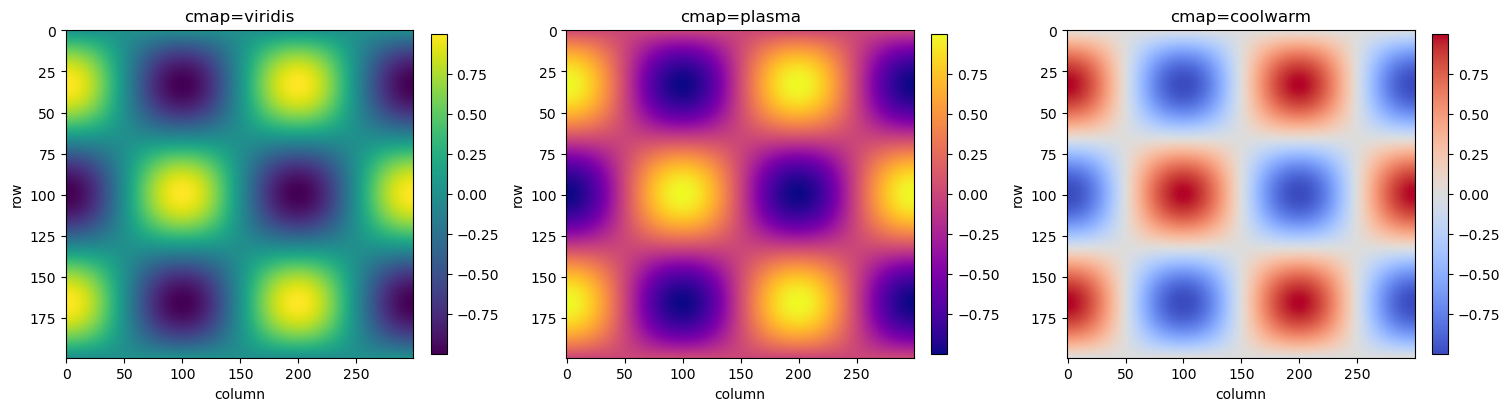

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmaps = ['viridis', 'plasma', 'coolwarm']
for ax, cmap_name in zip(axes, cmaps):
    im = ax.imshow(image_data, cmap=cmap_name, aspect='auto')
    ax.set_title(f'cmap={cmap_name}')
    ax.set_xlabel('column')
    ax.set_ylabel('row')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.show()

## 7) Heatmap / image rendering with different colormaps

This is useful for seeing how the same matrix can look very different depending on the colormap.

In [78]:
from pathlib import Path

# Updated path to the new assets folder
output_dir = Path('assets')
output_dir.mkdir(parents=True, exist_ok=True)

settings = [
    {'figsize': (4, 3), 'dpi': 72, 'name': 'line_small_72dpi.png'},
    {'figsize': (6, 4), 'dpi': 100, 'name': 'line_medium_100dpi.png'},
    {'figsize': (8, 5), 'dpi': 200, 'name': 'line_large_200dpi.png'},
]

saved_files = []
for cfg in settings:
    fig, ax = plt.subplots(figsize=cfg['figsize'])
    ax.plot(x, y1, color='royalblue', linewidth=2, label='sin(x)')
    ax.plot(x, y2, color='darkorange', linewidth=2, label='cos(x)')
    ax.set_title(f"size={cfg['figsize']}, dpi={cfg['dpi']}")
    ax.set_xlabel('x')
    ax.set_ylabel('value')
    ax.legend()
    ax.grid(alpha=0.25)

    path = output_dir / cfg['name']
    fig.savefig(path, dpi=cfg['dpi'], bbox_inches='tight')
    saved_files.append(path)
    plt.close(fig)

print('Saved files updated:')
for f in saved_files:
    print(f)

Saved files updated:
assets/line_small_72dpi.png
assets/line_medium_100dpi.png
assets/line_large_200dpi.png


from IPython.display import Image, display

# Path updated to point to the new assets folder
for f in sorted(Path('assets').glob('*.png')):
    print(f.name)
    display(Image(filename=str(f)))

In [79]:
from pathlib import Path

# Updated path to the new assets folder
output_dir = Path('assets')
output_dir.mkdir(parents=True, exist_ok=True)

settings = [
    {'figsize': (4, 3), 'dpi': 72, 'name': 'line_small_72dpi.png'},
    {'figsize': (6, 4), 'dpi': 100, 'name': 'line_medium_100dpi.png'},
    {'figsize': (8, 5), 'dpi': 200, 'name': 'line_large_200dpi.png'},
]

saved_files = []
for cfg in settings:
    fig, ax = plt.subplots(figsize=cfg['figsize'])
    ax.plot(x, y1, color='royalblue', linewidth=2, label='sin(x)')
    ax.plot(x, y2, color='darkorange', linewidth=2, label='cos(x)')
    ax.set_title(f"size={cfg['figsize']}, dpi={cfg['dpi']}")
    ax.set_xlabel('x')
    ax.set_ylabel('value')
    ax.legend()
    ax.grid(alpha=0.25)

    path = output_dir / cfg['name']
    fig.savefig(path, dpi=cfg['dpi'], bbox_inches='tight')
    saved_files.append(path)
    plt.close(fig)

print('Saved files updated:')
for f in saved_files:
    print(f)

Saved files updated:
assets/line_small_72dpi.png
assets/line_medium_100dpi.png
assets/line_large_200dpi.png


line_large_200dpi.png


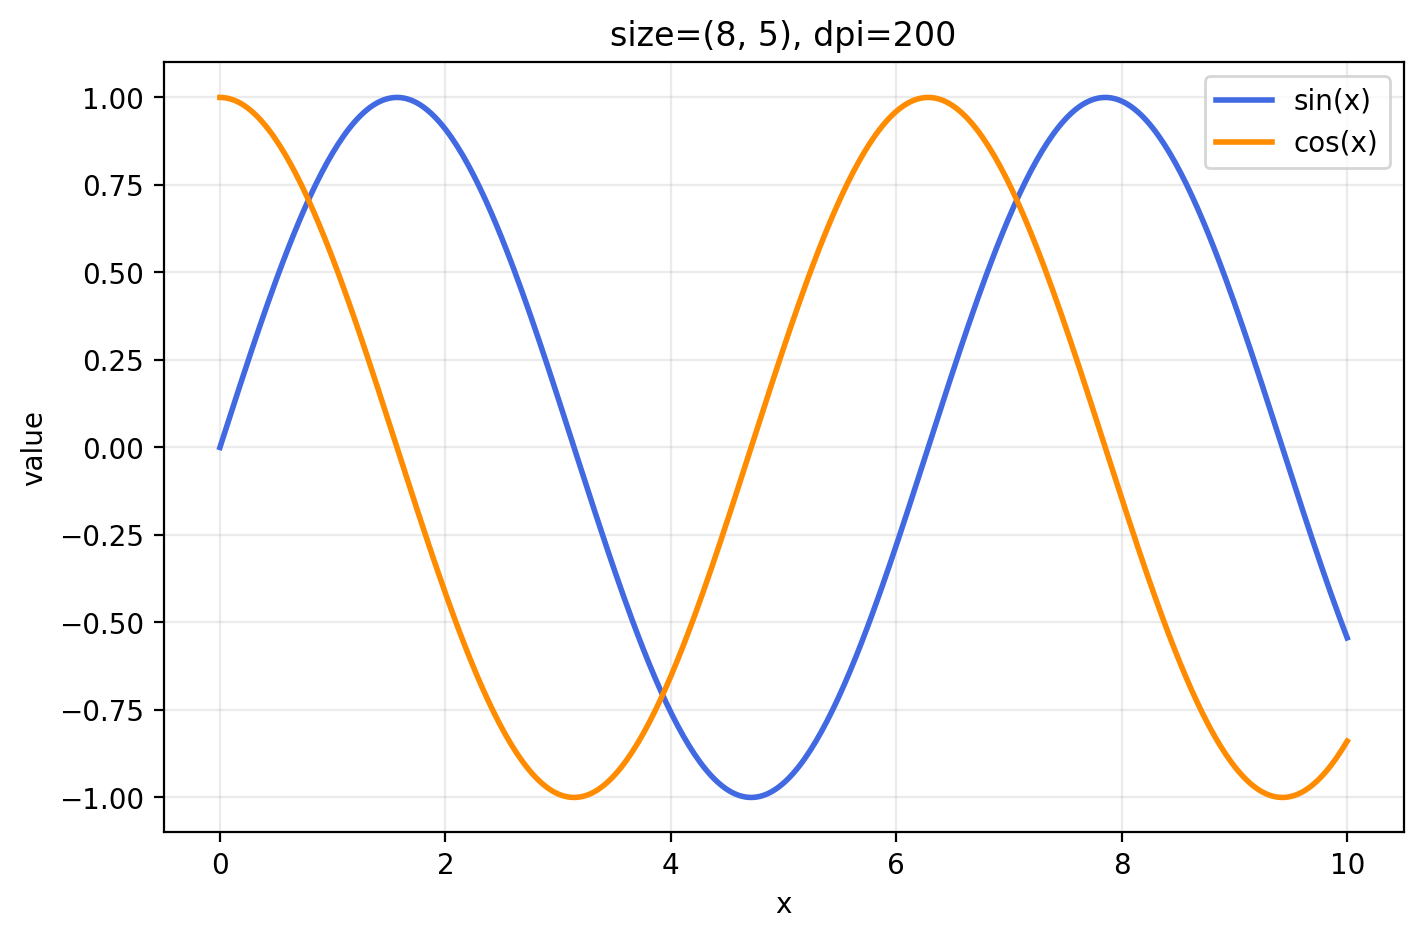

line_medium_100dpi.png


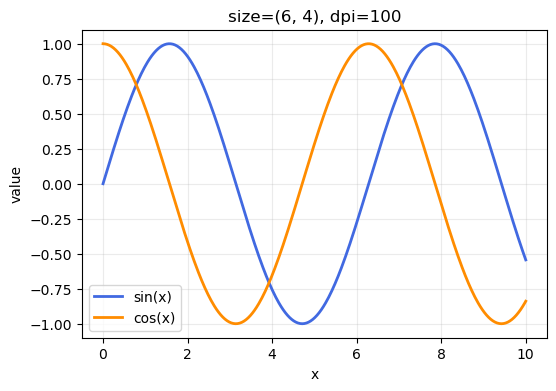

line_small_72dpi.png


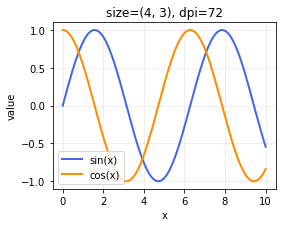

In [80]:
from IPython.display import Image, display

# Path updated to point to the new assets folder
for f in sorted(Path('assets').glob('*.png')):
    print(f.name)
    display(Image(filename=str(f)))

## 9) Optional: quick reference

Things that most affect appearance:

- `figsize=(w, h)` controls figure dimensions in inches
- `dpi=` controls export resolution
- `color=` changes line/bar/marker color
- `cmap=` changes image/heatmap colormap
- `alpha=` changes transparency
- `linewidth=`, `linestyle=`, `marker=` change line aesthetics
- `plt.style.use(...)` changes the overall theme

## 10) A Very, Very, Very Tall Plot
This plot demonstrates how Matplotlib handles extremely large vertical aspect ratios.

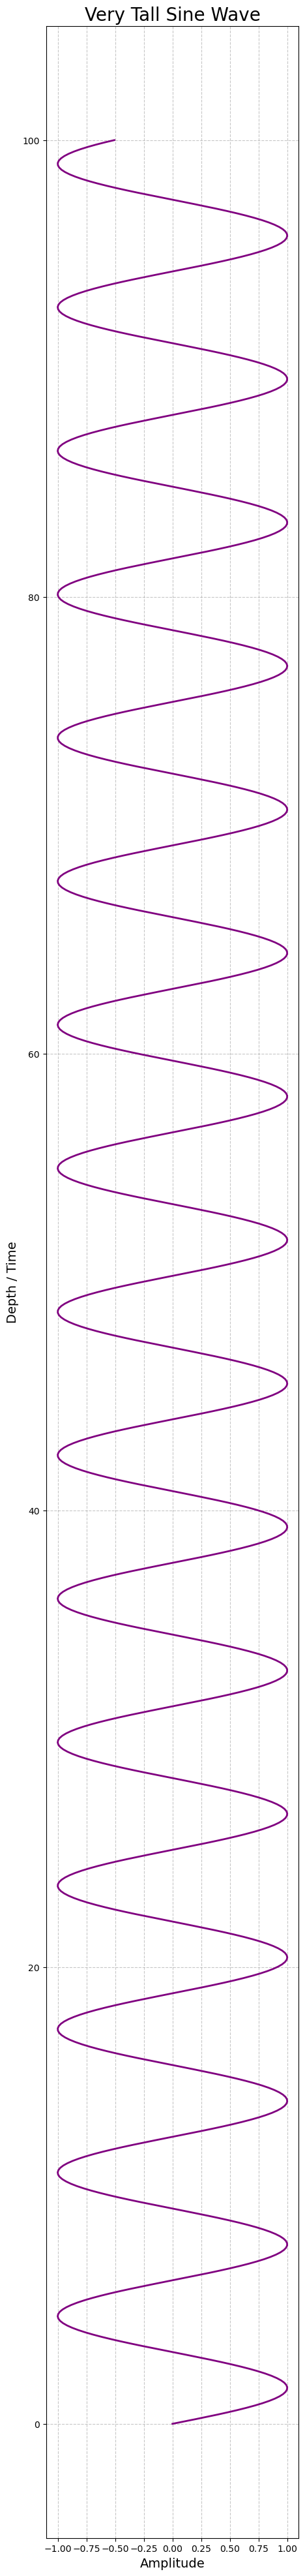

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Create data for a tall plot
y = np.linspace(0, 100, 1000)
x = np.sin(y)

# Set a very tall figure size (width=5, height=50)
fig, ax = plt.subplots(figsize=(5, 50))

ax.plot(x, y, color='purple', linewidth=2)
ax.set_title("Very Tall Sine Wave", fontsize=20)
ax.set_xlabel("Amplitude", fontsize=14)
ax.set_ylabel("Depth / Time", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 11) A Very, Very, Very Wide Plot
This plot demonstrates how Matplotlib handles extremely large horizontal aspect ratios.

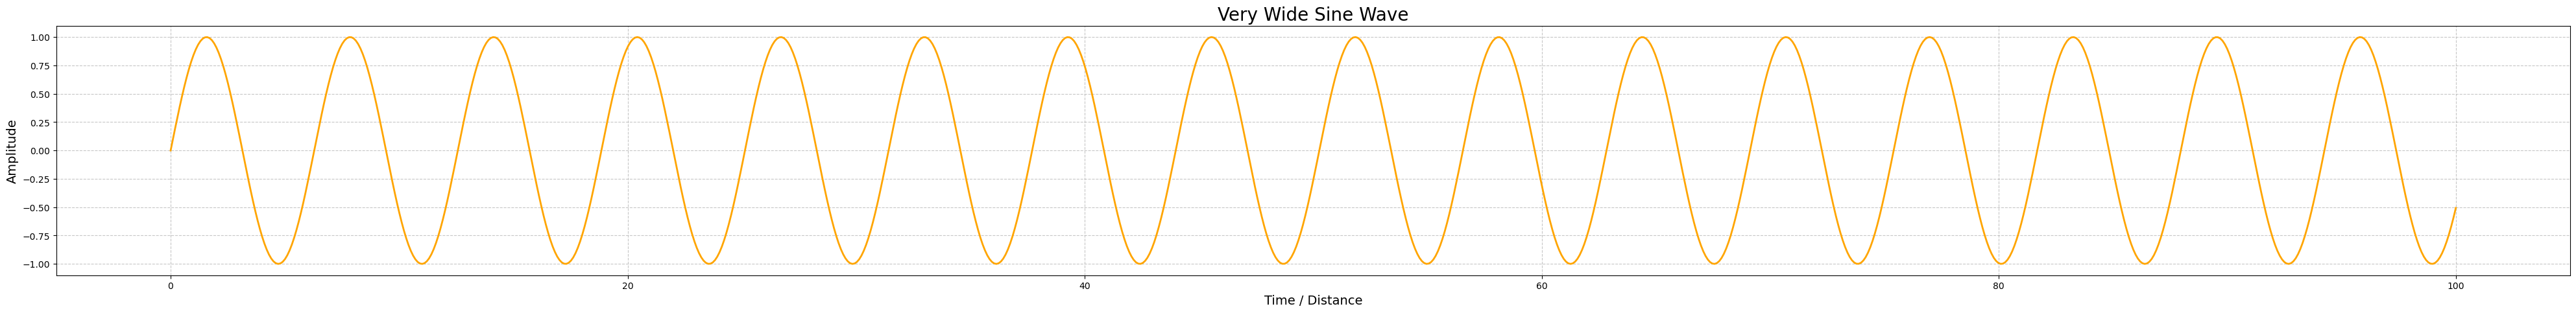

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Create data for a wide plot
x = np.linspace(0, 100, 1000)
y = np.sin(x)

# Set a very wide figure size (width=50, height=5)
fig, ax = plt.subplots(figsize=(50, 5))

ax.plot(x, y, color='orange', linewidth=2)
ax.set_title("Very Wide Sine Wave", fontsize=20)
ax.set_xlabel("Time / Distance", fontsize=14)
ax.set_ylabel("Amplitude", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()